# Volatility and the planning rate

**Notebook 2 of 2.**

Notebook 1 ended at a wall: nothing beats persistence on direction. Its
exploration section showed the size of moves has memory even when the sign doesn't. This notebook
forecasts that size, switches to the target with a direct business use — next
month's average rate — and closes with an input idea (the Fed's policy
language) that was tested and rejected.

## 1. Data wrangling — realised volatility from daily closes

In [1]:
import json as jsonlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="deep")
RAW = Path("../data/raw")
PAIRS = {"EURUSD": "EURUSD_X", "USDJPY": "JPY_X", "USDINR": "INR_X"}
SEED, EPS = 42, 1e-8

closes = {p: pd.read_parquet(RAW / f"{f}.parquet")["close"].dropna()
          for p, f in (PAIRS | {"DXY": "DX-Y_NYB", "VIX": "_VIX"}).items()}

def vol_frame(pair):
    """Trailing realised-vol components + lagged market features."""
    idx = closes[pair].index.intersection(closes["DXY"].index).intersection(closes["VIX"].index)
    c = closes[pair].loc[idx]
    r = np.log(c).diff()
    f = pd.DataFrame(index=idx)
    f["r2"] = r ** 2
    f["rv_d"] = r.abs()                                   # yesterday
    f["rv_w"] = np.sqrt(f["r2"].rolling(5).mean())        # last week
    f["rv_m"] = np.sqrt(f["r2"].rolling(21).mean())       # last month
    # market features, lagged one day (same stamp trap as notebook 1)
    f["vix"] = closes["VIX"].shift(1).reindex(idx)
    f["dxy_5d"] = np.log(closes["DXY"].shift(1)).diff(5).reindex(idx)
    f["shock"] = f["rv_d"] / (f["rv_m"] + EPS)
    mom_f, mom_s = np.log(c).diff(21), np.log(c).diff(252)
    f["mom_agree"] = (np.sign(mom_f) == np.sign(mom_s)).astype(float)
    return f

vols = {p: vol_frame(p) for p in PAIRS}
vols["EURUSD"].tail(3).round(5)

,r2,rv_d,rv_w,rv_m,vix,dxy_5d,shock,mom_agree
date,,,,,,,,
2026-07-29,0.00000,0.00150,0.00199,0.00248,18.21,0.00197,0.60454,0.0
2026-07-30,0.00005,0.00706,0.00372,0.00284,20.66,-0.00337,2.48720,0.0
2026-07-31,0.00002,0.00490,0.00409,0.00303,17.09,-0.01410,1.61666,0.0


Realised volatility — how much the price actually jumped around — is estimated
here from end-of-day prices, because intraday data was not available. That
makes it an approximation, and the claims are sized accordingly.

## 2. Data validation

In [2]:
checks = []
for pair, f in vols.items():
    clean = f.dropna()
    checks.append({"pair": pair, "rows": len(clean),
                   "start": clean.index[0].date(), "end": clean.index[-1].date(),
                   "negative_rv": int((clean[["rv_d", "rv_w", "rv_m"]] < 0).sum().sum()),
                   "zero_rv_w": int((clean["rv_w"] == 0).sum()),
                   "max_gap_days": int(clean.index.to_series().diff().dt.days.max())})
    assert clean.index.is_monotonic_increasing
    assert (clean[["rv_w", "rv_m"]] > 0).all().all()
pd.DataFrame(checks)

,pair,rows,start,end,negative_rv,zero_rv_w,max_gap_days
0,EURUSD,2884,2015-02-03,2026-07-31,0,0,5
1,USDJPY,2884,2015-02-03,2026-07-31,0,0,5
2,USDINR,2884,2015-02-03,2026-07-31,0,0,5


## 3. Exploratory analysis

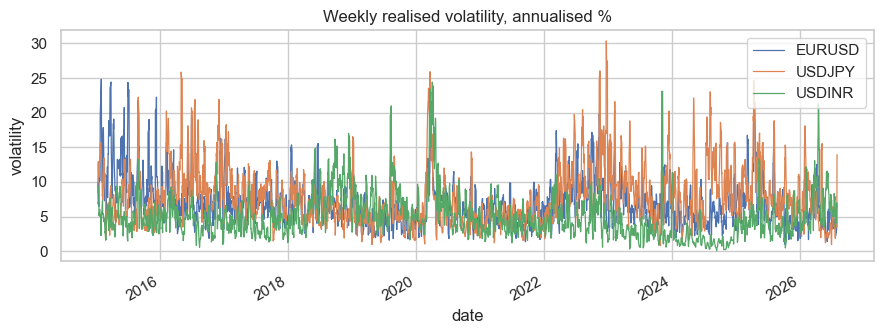

In [3]:
# The clustering from notebook 1's exploration, now on the modelling target.
rv = pd.DataFrame({p: vols[p]["rv_w"] * np.sqrt(252) * 100 for p in PAIRS}).dropna()
ax = rv.plot(figsize=(9, 3.5), linewidth=0.9)
ax.set_title("Weekly realised volatility, annualised %")
ax.set_ylabel("volatility")
plt.tight_layout()

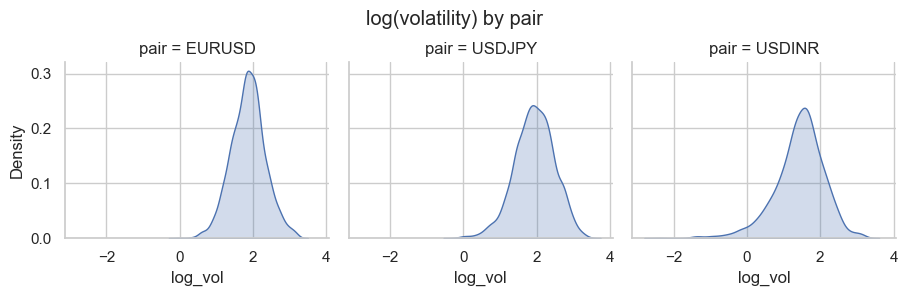

In [4]:
# Shape check for the next section's model: it works on log volatility,
# so log volatility had better look reasonably bell-shaped. It does.
logrv = np.log(rv.stack()).rename("log_vol").reset_index().rename(columns={"level_1": "pair"})
g = sns.displot(logrv, x="log_vol", col="pair", kind="kde", fill=True,
                height=2.8, aspect=1.1)
g.figure.suptitle("log(volatility) by pair", y=1.05);

Two shape checks before modelling. First: calm and stormy stretches cluster,
so recent roughness should help predict coming roughness. Second: measured on a
log scale, volatility has a clean bell-ish shape — which means the textbook
recipe used in the next section (a linear model on log volatility) is
applicable here.

## 4. Volatility models

Three contenders, walk-forward, each week forecast exactly once:

- **the do-nothing guess** — assume the current volatility continues;
- **HAR** — a linear model on yesterday's, last week's and last month's
  volatility;
- **HAR + ML** — the same three inputs plus market extras (the VIX, dollar
  moves, recent volatility shocks, and whether short- and long-term trends
  point the same way) fed to gradient boosting.

Scored with **QLIKE** (the standard volatility loss — punishes forecasting calm
before a storm harder than the reverse) and MAE (the plain average miss) on log
volatility. Lower is better.

In [5]:
def run_vol_models(f, fwd, refit, min_train):
    """Walk-forward RW / HAR / HAR+ML for one pair, one horizon."""
    target = np.sqrt(f["r2"].shift(-1).rolling(fwd).mean().shift(-(fwd - 1)))
    valid = f.dropna().index.intersection(target.dropna().index)
    origins = valid[::fwd]                      # non-overlapping windows
    y = np.log(target.loc[origins] + EPS)
    X_har = np.log(f.loc[origins, ["rv_d", "rv_w", "rv_m"]] + EPS)
    exog = f.loc[origins, ["vix", "dxy_5d", "shock", "mom_agree"]]
    X_ml = pd.concat([X_har, exog], axis=1)
    rw = np.log(f.loc[origins, "rv_w" if fwd == 5 else "rv_m"] + EPS).to_numpy()
    preds = {"do-nothing guess": rw,
             "HAR": np.full(len(y), np.nan), "HAR + ML": np.full(len(y), np.nan)}
    for start in range(min_train, len(y), refit):
        end = min(start + refit, len(y))
        tr = slice(0, start)
        preds["HAR"][start:end] = LinearRegression().fit(X_har.iloc[tr], y.iloc[tr]) \
            .predict(X_har.iloc[start:end])
        gbr = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05,
                                        subsample=0.8, random_state=SEED)
        preds["HAR + ML"][start:end] = gbr.fit(X_ml.iloc[tr], y.iloc[tr]) \
            .predict(X_ml.iloc[start:end])
    keep = ~np.isnan(preds["HAR"])
    y_t = y.to_numpy()[keep]
    rows = []
    for name, p in preds.items():
        p = p[keep]
        s, h = np.exp(2 * y_t), np.exp(2 * p)
        rows.append({"model": name, "n": int(keep.sum()),
                     "qlike": np.mean(s / h - np.log(s / h) - 1),
                     "mae_log": np.mean(np.abs(p - y_t))})
    series = pd.DataFrame({"date": origins[keep], "actual": np.exp(y_t),
                           "har": np.exp(preds["HAR"][keep])})
    return pd.DataFrame(rows), series

results, har_series = [], {}
for pair in PAIRS:
    for horizon, fwd, refit, min_train in [("next week", 5, 13, 150),
                                           ("next month", 21, 3, 40)]:
        table, series = run_vol_models(vols[pair], fwd, refit, min_train)
        results.append(table.assign(pair=pair, horizon=horizon))
        if horizon == "next week":
            har_series[pair] = series
results = pd.concat(results)
results.pivot_table(index=["pair", "horizon"], columns="model",
                    values="qlike").round(3)[["do-nothing guess", "HAR", "HAR + ML"]]

model              do-nothing guess    HAR  HAR + ML
pair   horizon                                      
EURUSD next month             0.181  0.153     0.218
       next week              0.840  0.360     0.418
USDINR next month             0.626  0.488     0.471
       next week              1.721  0.841     1.000
USDJPY next month             0.335  0.259     0.370
       next week              1.130  0.550     0.661

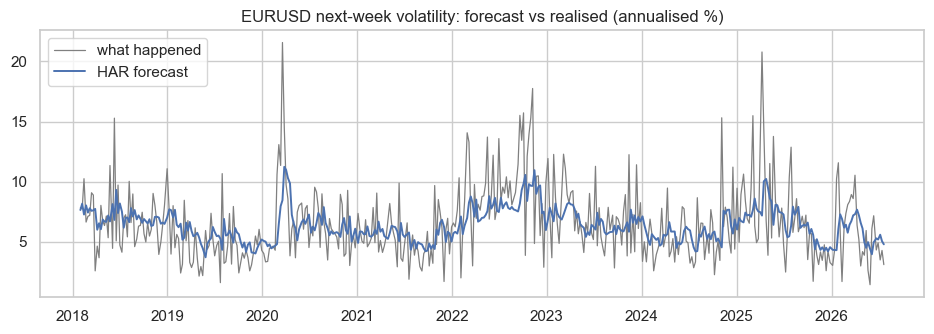

In [6]:
# Eyeball check on the headline number: does the HAR line actually track
# realised vol, or is the QLIKE gap a metric artifact?
s = har_series["EURUSD"]
fig, ax = plt.subplots(figsize=(9.5, 3.5))
ax.plot(s["date"], s["actual"] * np.sqrt(252) * 100, color="gray", linewidth=0.9,
        label="what happened")
ax.plot(s["date"], s["har"] * np.sqrt(252) * 100, linewidth=1.4, label="HAR forecast")
ax.set_title("EURUSD next-week volatility: forecast vs realised (annualised %)")
ax.legend()
plt.tight_layout()

Two results:

1. HAR roughly halves the weekly forecast error versus the do-nothing guess,
   on all three pairs.
2. The ML layer is worse in five of six cells (only USDINR monthly improves).
   It stays in the table as the negative result it is.

## 5. Next month's average rate — the question with a business answer

Budgets, contracts and pricing sheets need one rate agreed in advance, and what
they implicitly forecast is next month's **average** — a different target from any
day's close, with its own correct baseline. Three ways to set it, compared at each
month-end:

- carry forward **last month's average** (the common reporting habit);
- carry forward **today's rate**;
- a small statistical model (an "AR" model) that continues recent daily moves
  forward and averages the projected month.

In [7]:
def month_average_test(pair):
    c = closes[pair]
    m_avg, m_close = c.resample("ME").mean(), c.resample("ME").last()
    r = np.log(c).diff().dropna()
    rows = []
    for i in range(1, len(m_avg) - 1):
        if c.index[-1] < m_avg.index[i + 1]:
            break                                # target month not finished
        hist = r[r.index <= m_avg.index[i]]
        if len(hist) < 756:
            continue
        h = hist.iloc[-756:]
        mu, phi, last = h.mean(), h.autocorr(1), h.iloc[-1]
        path = np.cumsum([mu + phi ** k * (last - mu) for k in range(1, 22)])
        rows.append({"actual": m_avg.iloc[i + 1],
                     "last month's average": m_avg.iloc[i],
                     "today's rate": m_close.iloc[i],
                     "AR model": np.mean(m_close.iloc[i] * np.exp(path))})
    df = pd.DataFrame(rows)
    return pd.Series({k: (df[k] - df["actual"]).abs().div(df["actual"]).mean() * 100
                      for k in df.columns[1:]}, name=pair), len(df)

pavg = pd.DataFrame([month_average_test(p)[0] for p in PAIRS])
n_months = month_average_test("EURUSD")[1]
print(f"{n_months} months per pair; mean absolute error, % of the realised average:")
pavg.round(2)

104 months per pair; mean absolute error, % of the realised average:


,last month's average,today's rate,AR model
EURUSD,1.21,1.01,1.03
USDJPY,1.51,1.13,1.14
USDINR,0.90,0.66,0.65


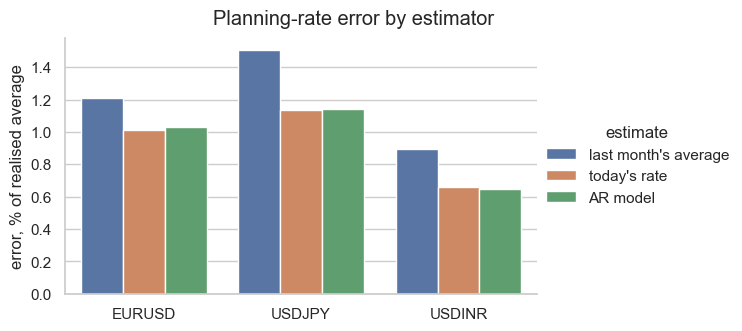

In [8]:
# The table above, as a chart: error per estimator on the same scale.
tidy = pavg.reset_index(names="pair").melt(id_vars="pair", var_name="estimate",
                                           value_name="mae_pct")
g = sns.catplot(tidy, x="pair", y="mae_pct", hue="estimate", kind="bar",
                height=3.4, aspect=1.7)
g.set_axis_labels("", "error, % of realised average")
g.figure.suptitle("Planning-rate error by estimator", y=1.03);

Carrying today's rate forward beats last month's average by 16–28% on every
pair, and the AR model adds nothing beyond it. The operational change costs
nothing: at each month-end, set the planning rate from today's rate instead of
last month's average.

## 6. Central-bank language

Do the Fed's words add anything the market data doesn't already carry? All 99
post-meeting statements (2015–2026) scored hawkish / neutral / dovish with a
dictionary method — deterministic, so every score is checkable.

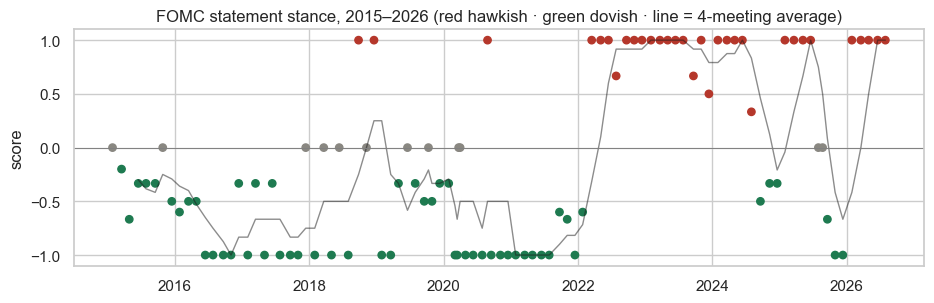

In [9]:
# Sanity-check the scorer against known policy eras before using it:
# 2022-23 should read hawkish, 2020 dovish.
stance = pd.read_parquet(RAW / "fomc" / "stance.parquet")
fig, ax = plt.subplots(figsize=(9.5, 3.2))
colors = stance["label"].map({"hawkish": "#b5372b", "neutral": "#898781",
                              "dovish": "#1e7a50"})
ax.scatter(stance.index, stance["score"], c=colors, s=28)
ax.plot(stance.index, stance["score"].rolling(4).mean(), color="k", linewidth=1,
        alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.7)
ax.set_title("FOMC statement stance, 2015–2026 "
             "(red hawkish · green dovish · line = 4-meeting average)")
ax.set_ylabel("score")
plt.tight_layout()

In [10]:
sent = jsonlib.load(open(RAW / "fomc" / "stance_sentences.json"))
print("2022-06-15 (75bp hike) — sample scored sentence:")
print("  ", next(s["sentence"] for s in sent["20220615"] if s["hawk"]))
print("2020-03-15 (emergency cut) — sample scored sentence:")
print("  ", next(s["sentence"] for s in sent["20200315"] if s["dove"]))

2022-06-15 (75bp hike) — sample scored sentence:
   Job gains have been robust in recent months, and the unemployment rate has remained low.
2020-03-15 (emergency cut) — sample scored sentence:
   Although household spending rose at a moderate pace, business fixed investment and exports remained weak.


As a measurement the scorer partially validates: the 2022–23 hiking cycle reads
hawkish, the 2020 emergency cuts read dovish, and it misses turns that lived in decisions
rather than adjectives (December 2015 — the first rate hike in a decade —
scores dovish, because the prose stayed gentle). Whether
it *predicts* anything is the test below — each model run with and without the
five stance inputs on the same 402 walk-forward weeks of USDINR
(`scripts/13_stance_ablation.py`):

In [11]:
ablation = pd.read_csv("../outputs/case_study/tables/stance_ablation.csv")
ablation[["model", "variant", "n", "accuracy", "balanced_accuracy", "brier"]]

,model,variant,n,accuracy,balanced_accuracy,brier
0,logistic,base,402,0.396,0.332,0.6910
1,logistic,with_stance,402,0.381,0.328,0.7030
2,logistic,brier_diff(base-stance),402,NaN,NaN,-0.0120
3,gradient_boosting,base,402,0.425,0.345,0.6990
4,gradient_boosting,with_stance,402,0.438,0.358,0.6880
5,gradient_boosting,brier_diff(base-stance),402,NaN,NaN,0.0108


Logistic got slightly worse with the stance inputs, gradient boosting slightly
better. The paired probability-score differences (the table's "brier" column —
lower is better) are −0.012 [−0.031, +0.005] and +0.011 [−0.017, +0.038]: both
uncertainty ranges include zero, so no measurable effect in either direction.
Rejected. (Accuracies below 50% are normal here — these are three-way guesses,
so random scores about 33%.)

## 7. Comparison against the benchmarks — the whole study in one table

In [12]:
summary = pd.DataFrame([
    {"question": "Direction: where does the rate go next?",
     "baseline": "next period repeats the last one",
     "result": "could not beat simple guessing (notebook 1)"},
    {"question": "Volatility: how big will the moves be?",
     "baseline": "today's volatility continues",
     "result": "HAR halves the next-week error on all 3 pairs"},
    {"question": "Planning: what rate for next month?",
     "baseline": "last month's average",
     "result": "today's close cuts error 16-28%, no model needed"},
    {"question": "Policy language as an input?",
     "baseline": "same models without stance",
     "result": "no measurable value — rejected"},
])
summary

,question,baseline,result
0,Direction: where does the rate go next?,next period repeats the last one,could not beat simple guessing (notebook 1)
1,Volatility: how big will the moves be?,today's volatility continues,HAR halves the next-week error on all 3 pairs
2,Planning: what rate for next month?,last month's average,"today's close cuts error 16-28%, no model needed"
3,Policy language as an input?,same models without stance,no measurable value — rejected


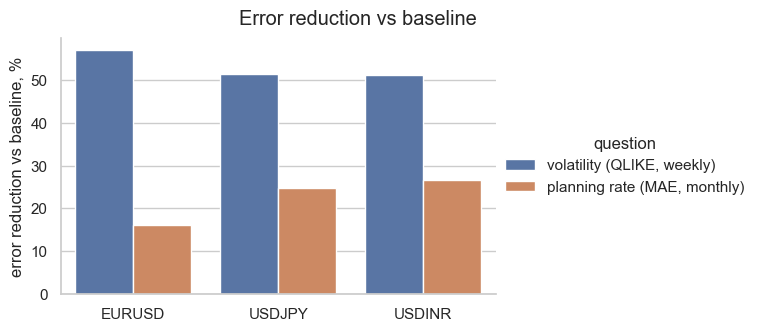

In [13]:
# Close the loop: what each answerable question earned over its baseline.
gains = []
for pair in PAIRS:
    r = results.query("pair == @pair and horizon == 'next week'").set_index("model")["qlike"]
    gains.append({"question": "volatility (QLIKE, weekly)", "pair": pair,
                  "error_cut_pct": (1 - r["HAR"] / r["do-nothing guess"]) * 100})
    gains.append({"question": "planning rate (MAE, monthly)", "pair": pair,
                  "error_cut_pct": (1 - pavg.loc[pair, "today's rate"]
                                    / pavg.loc[pair, "last month's average"]) * 100})
gains = pd.DataFrame(gains)
g = sns.catplot(gains, x="pair", y="error_cut_pct", hue="question", kind="bar",
                height=3.4, aspect=1.6)
g.set_axis_labels("", "error reduction vs baseline, %")
g.figure.suptitle("Error reduction vs baseline", y=1.03);

### Conclusion

Direction failed against the laziest baseline available. The same data halves
the volatility forecast error and cuts planning-rate error 16–28% — the work was
in picking the target and the baseline, not the algorithm.